# Metacommunity buffering

In [5]:
import numpy as np
import pyrepseq as prs

import matplotlib.pyplot as plt

import repertoire_simulator.lib as lib

plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

## The limit of strong migration - $M / D = 100$ 

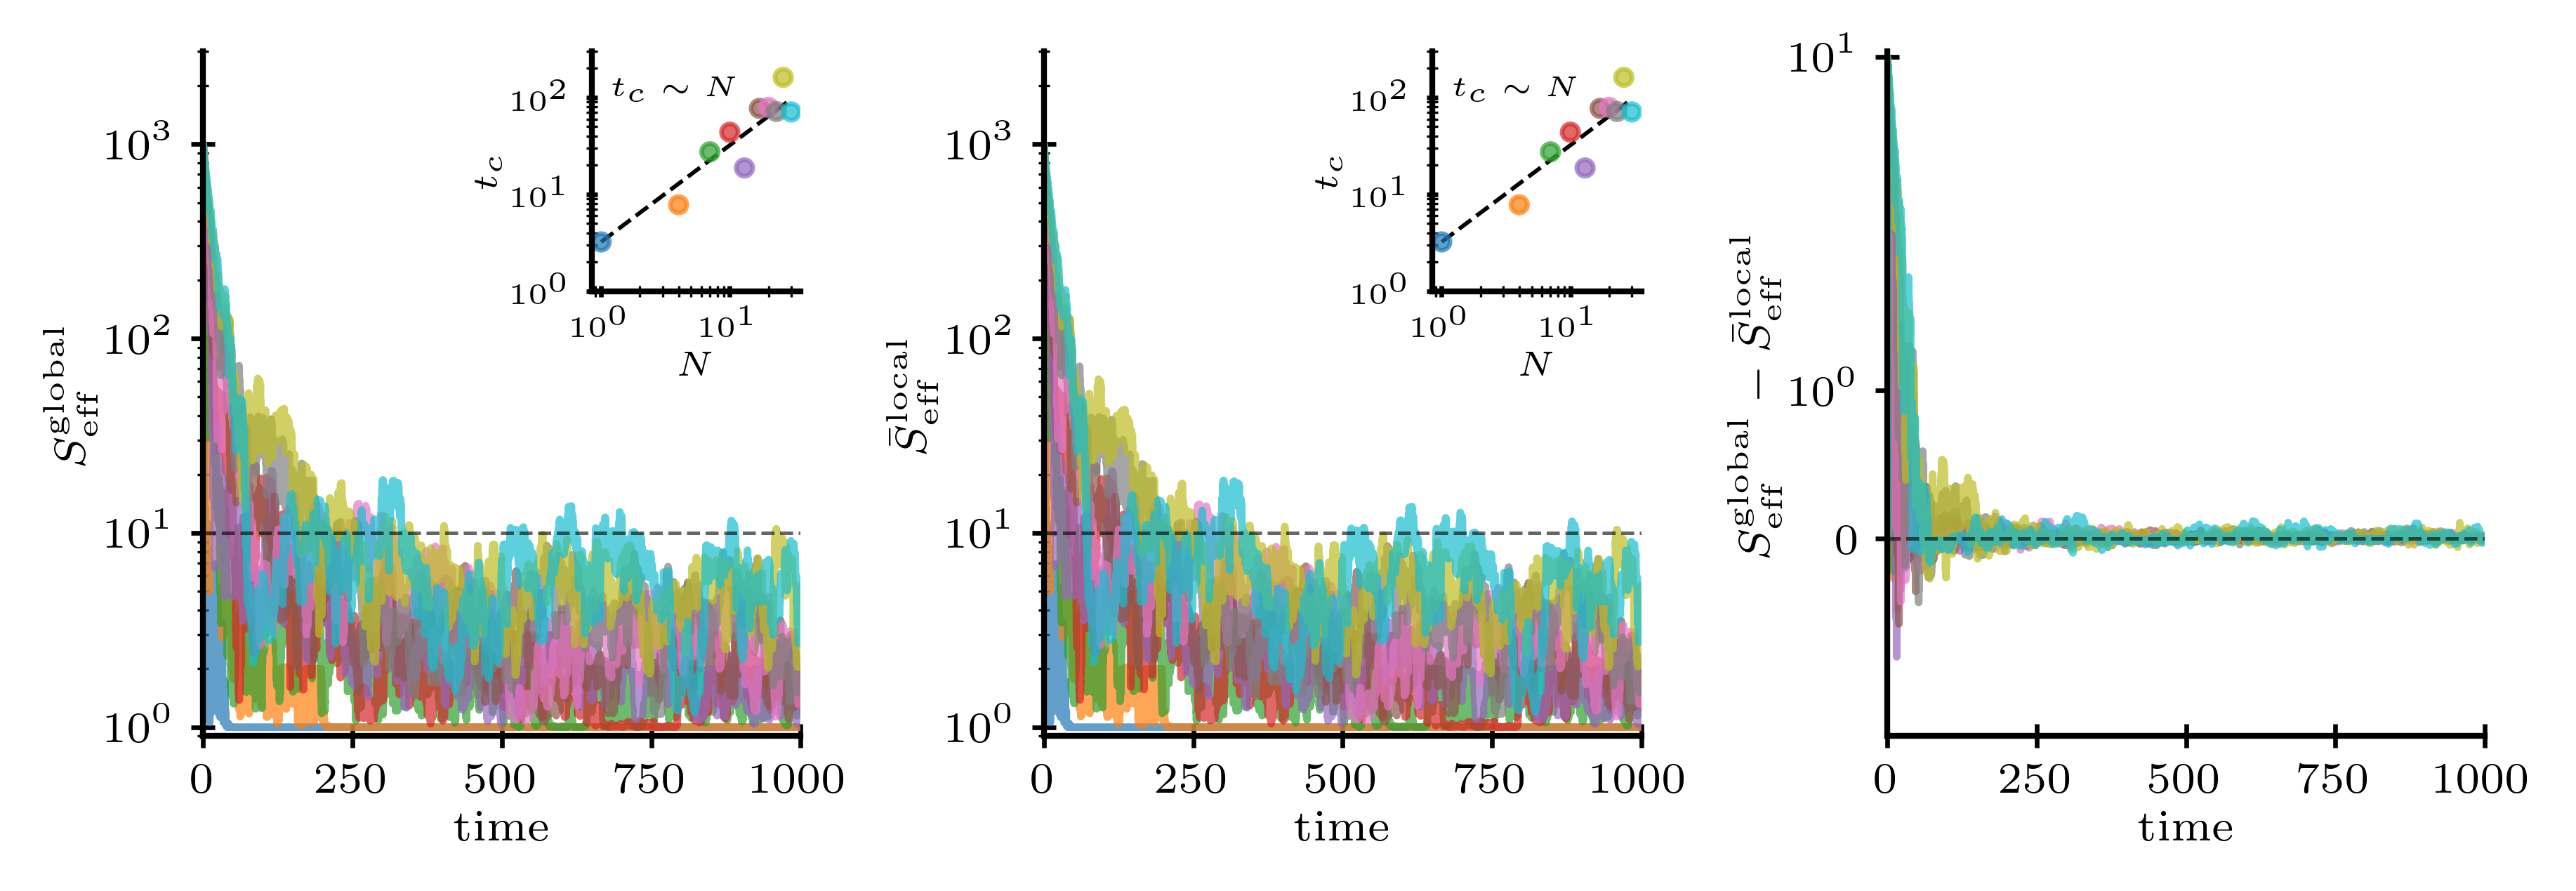

In [6]:
Ns = np.linspace(1, 30, 10).astype(int)
results_for_patches = {}
for N in Ns:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/metacommunity_buffering/strong_migration_limit/patches_{N}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff_global = np.zeros(len(t))
    Seff_local = np.zeros(len(t))
    
    for i, time in enumerate(t):
        Seff_global[i] = lib.get_global_simpsons_diversity(c_t[i])
        Seff_local[i] = lib.get_average_simpsons_diversity(c_t[i])
    
    results_for_patches[N] = {'t':t, 'Seff_global':Seff_global, 'Seff_local':Seff_local}


fig, ax = plt.subplots(1, 3, figsize=(6, 2), layout='constrained')

t_cs = np.full(len(Ns), np.nan)
t_cs_loc = np.full(len(Ns), np.nan)
colors = []
for i, N in enumerate(Ns):
    t = results_for_patches[N]['t']
    
    below = np.where(results_for_patches[N]['Seff_global'] <= 10)[0]
    below_loc = np.where(results_for_patches[N]['Seff_local'] <= 10)[0]
    if len(below) > 0:
        t_cs[i] = t[below[0]]
    if len(below_loc) > 0:
        t_cs_loc[i] = t[below_loc[0]]
        
    line, = ax[0].plot(t, results_for_patches[N]['Seff_global'], alpha=0.7)
    colors.append(line.get_color())
        
    ax[1].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_local'], alpha=0.7)
    ax[2].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_global'] - results_for_patches[N]['Seff_local'], alpha=0.7)

ax[0].axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)

ax[0].set_yscale('log')
ax[0].set_xlim(0, 1000)
ax[0].set_ylim(0.9, 3e3)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{global}}$')

inset1 = ax[0].inset_axes([0.65, 0.65, 0.35, 0.35])

mask1 = np.isfinite(t_cs)
inset1.scatter(Ns[mask1], t_cs[mask1], s=8, c=np.asarray(colors)[mask1], alpha=0.7)
inset1.plot(Ns, Ns*t_cs[0], linestyle='--', c='black', lw=0.7, zorder=-2)
inset1.text(0.1, 0.9, r'$t_c \sim N$', transform=inset1.transAxes, fontsize=5, ha='left',va='top')
inset1.set_xscale('log')
inset1.set_yscale('log')
inset1.set_ylim([1, 300])

inset1.set_xlabel(r'$N$', fontsize=6)
inset1.set_ylabel(r'$t_c$', fontsize=6)
inset1.tick_params(axis='both', labelsize=5, length=2)

ax[1].axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)
ax[1].set_xlim(0, 1000)
ax[1].set_ylim(0.9, 3e3)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'time')
ax[1].set_ylabel(r'$\bar{S}^{\mathrm{local}}_{\mathrm{eff}}$')


inset2 = ax[1].inset_axes([0.65, 0.65, 0.35, 0.35])

mask2 = np.isfinite(t_cs_loc)
inset2.scatter(Ns[mask2], t_cs_loc[mask2], s=8, c=np.asarray(colors)[mask2], alpha=0.7)
inset2.plot(Ns, Ns*t_cs[0], linestyle='--', c='black', lw=0.7, zorder=-2)
inset2.text(0.1, 0.9, r'$t_c \sim N$', transform=inset2.transAxes, fontsize=5, ha='left',va='top')
inset2.set_xscale('log')
inset2.set_yscale('log')
inset2.set_ylim([1, 300])

inset2.set_xlabel(r'$N$', fontsize=6)
inset2.set_ylabel(r'$t_c$', fontsize=6)
inset2.tick_params(axis='both', labelsize=5, length=2)

ax[2].set_xlim(0, 1000)
ax[2].axhline(0, color='k', lw=0.6, ls='--', alpha=0.6)
ax[2].set_xlabel(r'time')
ax[2].set_yscale('symlog')
ax[2].set_ylabel(r'$S^{\mathrm{global}}_{\mathrm{eff}} - \bar{S}^{\mathrm{local}}_{\mathrm{eff}}$')
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_patches_high_M.svg', bbox_inches='tight', dpi=200, transparent=True);

## The limit of weak migration - $M / D = 0.1$ 

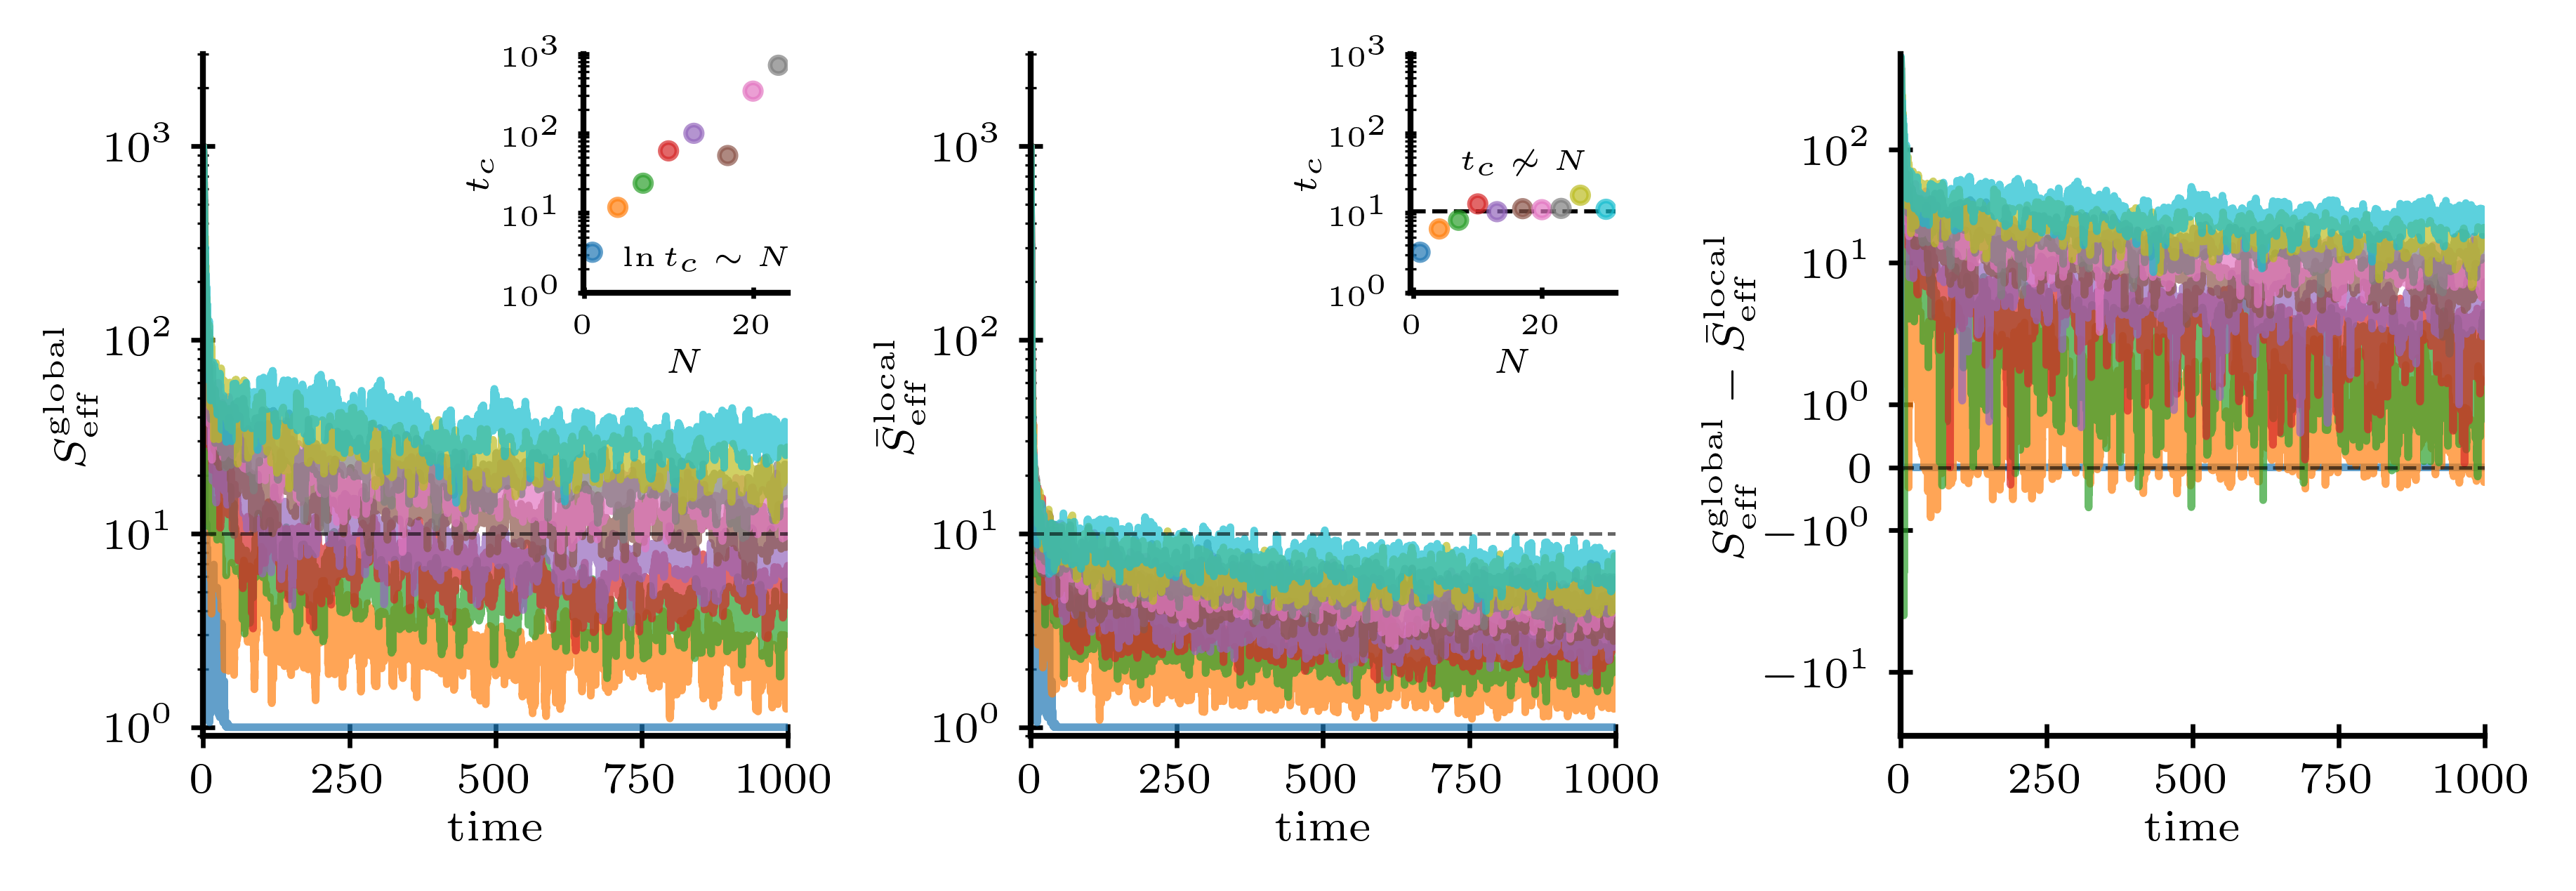

In [20]:
Ns = np.linspace(1, 30, 10).astype(int)
results_for_patches = {}
for N in Ns:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/metacommunity_buffering/weak_migration_limit/patches_{N}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff_global = np.zeros(len(t))
    Seff_local = np.zeros(len(t))
    
    for i, time in enumerate(t):
        Seff_global[i] = lib.get_global_simpsons_diversity(c_t[i])
        Seff_local[i] = lib.get_average_simpsons_diversity(c_t[i])
    
    results_for_patches[N] = {'t':t, 'Seff_global':Seff_global, 'Seff_local':Seff_local}


fig, ax = plt.subplots(1, 3, figsize=(6, 2), layout='constrained')

t_cs = np.full(len(Ns), np.nan)
t_cs_loc = np.full(len(Ns), np.nan)
colors = []
for i, N in enumerate(Ns):
    t = results_for_patches[N]['t']
    
    below = np.where(results_for_patches[N]['Seff_global'] <= 10)[0]
    below_loc = np.where(results_for_patches[N]['Seff_local'] <= 10)[0]
    if len(below) > 0:
        t_cs[i] = t[below[0]]
    if len(below_loc) > 0:
        t_cs_loc[i] = t[below_loc[0]]
        
    line, = ax[0].plot(t, results_for_patches[N]['Seff_global'], alpha=0.7)
    colors.append(line.get_color())
        
    ax[1].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_local'], alpha=0.7)
    ax[2].plot(results_for_patches[N]['t'], results_for_patches[N]['Seff_global'] - results_for_patches[N]['Seff_local'], alpha=0.7)

ax[0].axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)

ax[0].set_yscale('log')
ax[0].set_xlim(0, 1000)
ax[0].set_ylim(0.9, 3e3)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{global}}$')

inset1 = ax[0].inset_axes([0.65, 0.65, 0.35, 0.35])

mask1 = np.isfinite(t_cs)
inset1.scatter(Ns[mask1], t_cs[mask1], s=8, c=np.asarray(colors)[mask1], alpha=0.7)
# inset1.plot(Ns, np.exp((np.log(t_cs[2]) / Ns[2]) * Ns), linestyle='--', c='black', lw=0.7, zorder=-2)
inset1.text(0.2, 0.2, r'$\ln t_c \sim N$', transform=inset1.transAxes, fontsize=5, ha='left',va='top')
inset1.set_yscale('log')
inset1.set_ylim([1, 1000])

inset1.set_xlabel(r'$N$', fontsize=6)
inset1.set_ylabel(r'$t_c$', fontsize=6)
inset1.tick_params(axis='both', labelsize=5, length=2)

ax[1].axhline(10, color='k', lw=0.6, ls='--', alpha=0.6)
ax[1].set_xlim(0, 1000)
ax[1].set_ylim(0.9, 3e3)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'time')
ax[1].set_ylabel(r'$\bar{S}^{\mathrm{local}}_{\mathrm{eff}}$')


inset2 = ax[1].inset_axes([0.65, 0.65, 0.35, 0.35])

mask2 = np.isfinite(t_cs_loc)
inset2.scatter(Ns[mask2], t_cs_loc[mask2], s=8, c=np.asarray(colors)[mask2], alpha=0.7)
inset2.axhline(t_cs_loc[4], color='k', lw=0.7, ls='--', zorder=-2)
inset2.text(0.25, 0.6, r'$t_c \not\sim N$', transform=inset2.transAxes, fontsize=5, ha='left',va='top')
inset2.set_yscale('log')
inset2.set_ylim([1, 1000])

inset2.set_xlabel(r'$N$', fontsize=6)
inset2.set_ylabel(r'$t_c$', fontsize=6)
inset2.tick_params(axis='both', labelsize=5, length=2)

ax[2].set_xlim(0, 1000)
ax[2].axhline(0, color='k', lw=0.6, ls='--', alpha=0.6)
ax[2].set_xlabel(r'time')
ax[2].set_yscale('symlog')
ax[2].set_ylabel(r'$S^{\mathrm{global}}_{\mathrm{eff}} - \bar{S}^{\mathrm{local}}_{\mathrm{eff}}$')
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_patches_low_M.svg', bbox_inches='tight', dpi=200, transparent=True);

## Influence on repertoire diversity fluctuations